# **Experiment Notebook**



---
## Setup Environment

In [59]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT2/data


---
## Student Information

In [60]:
# <Student to fill this section>
student_name = "SUSHRUTA GANGADHAR PATIL"
student_id = "26273312"

In [61]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [62]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

### 0.b Import Packages

In [63]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

---
## A. Experiment Description

In [64]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "2"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [65]:
experiment_hypothesis = """

Random Forest with class_weight='balanced_subsample' and RandomizedSearchCV
should outperform the Decision Tree from Experiment 1, which achieved a macro
F1 of 0.6809.

Experiment 1 showed that a single Decision Tree has a cross-val to validation
gap of 0.06, meaning it overfits to some degree. The tree also struggled with
Scurvy at 0.513 F1 and Night_Blindness at 0.500 F1 despite having direct
nutrient signals for both classes. The root cause is that a single tree makes
hard, high-variance splits, a small change in training data can produce a
completely different tree.

Random Forest fixes this by building many trees on different bootstrap samples
and averaging their predictions. This reduces variance significantly and produces
more stable class boundaries, particularly for minority classes with few training
samples like Scurvy (95) and Night_Blindness (134).

balanced_subsample applies class balancing independently within each bootstrap
sample rather than globally. This means every tree in the forest sees a balanced
view of the data, giving minority classes consistent representation across the
entire ensemble.

"""

In [66]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [67]:
experiment_expectations = """
Target: macro F1 above 0.80 on the validation set, with Scurvy and
Night_Blindness F1 both above 0.60.

Three ways this could go:

1. It works well (macro F1 above 0.85): The ensemble variance reduction
   is enough to stabilise minority class boundaries. Scurvy and
   Night_Blindness both cross 0.65 F1 and majority classes improve further.

2. It works partially (macro F1 between 0.75 and 0.85): Majority classes
   improve and the cross-val to validation gap closes, but Scurvy and
   Night_Blindness remain below 0.65 due to limited training samples.
   Macro F1 clears the 0.75 target but falls short of 0.85.

3. It doesn't improve enough (macro F1 below 0.75): Random Forest overfits
   on majority classes despite balanced_subsample. This would point to the
   data imbalance needing direct treatment through oversampling in the
   next experiment rather than just algorithmic fixes.
"""

In [68]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [69]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

In [70]:
# Shape and feature overview
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# Class distribution in training set
print("\nClass distribution (train):")
print(y_train['disease_diagnosis'].value_counts())

# Feature summary
print("\nFeature types:")
print(X_train.dtypes.value_counts())

# Quick stats on key features
print("\nKey feature statistics:")
X_train.describe().round(2)

X_train shape: (3221, 29)
X_val shape:   (690, 29)
X_test shape:  (691, 29)

Class distribution (train):
disease_diagnosis
Healthy                 1182
Anemia                  1002
Rickets_Osteomalacia     808
Night_Blindness          134
Scurvy                    95
Name: count, dtype: int64

Feature types:
int64      15
float64    14
Name: count, dtype: int64

Key feature statistics:


,serum_vitamin_d,serum_vitamin_b12,serum_folate,vitamin_a_intake,vitamin_c_intake,vitamin_d_intake,vitamin_b12_intake,folate_intake,calcium_intake,iron_intake,...,Peripheral neuropathy,has_memory_problems,has_pale_skin,rickets_symptom_score,scurvy_symptom_score,anemia_symptom_score,night_blindness_symptom_score,diet_sun_risk,vitamin_d_calcium_product,vegan_b12_risk
count,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,...,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00
mean,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,...,0.35,0.30,0.16,0.57,0.32,0.65,0.38,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,0.48,0.46,0.37,0.78,0.53,0.84,0.58,1.00,1.00,1.00
min,-1.57,-1.26,-2.08,-2.19,-2.19,-1.61,-1.61,-2.31,-2.16,-2.04,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.45,-1.12,-1.61
25%,-0.73,-0.86,-0.75,-0.76,-0.75,-0.75,-0.80,-0.74,-0.73,-0.74,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.60,-0.70,-0.56
50%,-0.21,-0.22,-0.21,-0.12,-0.10,-0.21,-0.20,-0.13,-0.13,-0.12,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.25,-0.31,-0.56
75%,0.46,0.56,0.58,0.72,0.65,0.56,0.63,0.66,0.65,0.57,...,1.00,1.00,0.00,1.00,1.00,1.00,1.00,0.25,0.40,-0.18
max,4.32,5.49,2.88,3.34,4.39,4.77,4.93,3.64,3.65,4.07,...,1.00,1.00,1.00,2.00,2.00,2.00,2.00,1.94,5.77,2.32


---
## D. Feature Selection


In [71]:
features_list = [
    # Serum biomarkers
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',

    # Raw intake
    'vitamin_a_intake', 'vitamin_c_intake',

    # Engineered symptom scores
    'rickets_symptom_score', 'anemia_symptom_score',

    # Engineered interaction features
    'diet_sun_risk', 'vitamin_d_calcium_product', 'vegan_b12_risk',

    # New engineered features
    'vitamin_a_night_risk', 'vitamin_c_scurvy_risk',

    # Lifestyle
    'sun_exposure_type',

    # General severity
    'symptoms_count'
]

In [72]:
feature_selection_explanations = """
14 features are selected for this experiment, refined from Experiment 1's 16.

Experiment 1's feature importance plot was the main guide here. diet_type and
income_band contributed near zero and are dropped. night_blindness_symptom_score
and scurvy_symptom_score also ranked near the bottom once vitamin_a_intake and
vitamin_c_intake were in the model, the symptom score versions of these added
little on top.

Two new engineered features replace them, vitamin_a_night_risk and
vitamin_c_scurvy_risk. These are created in section F and directly target
the two weakest classes from Experiment 1.

The remaining features are kept based on their demonstrated importance,
vitamin_c_intake and vitamin_a_intake ranked first and second in Experiment 1,
serum_vitamin_d third. The symptom scores for Rickets and Anemia stay in as
they showed meaningful separation for those classes.
"""

In [73]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>


In [74]:
data_transformation_1_explanations = """
All transformations were done in the preparation notebook: scaling, encoding,
imputation. Nothing left to do here. The splits load clean and ready to use.
"""

In [75]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "vitamin_a_night_risk"



In [76]:
for df in [X_train, X_val, X_test]:
    df['vitamin_a_night_risk'] = df['vitamin_a_intake'] * df['has_night_blindness']

In [77]:
feature_engineering_1_explanations = """
vitamin_a_night_risk is the product of vitamin_a_intake and has_night_blindness.

Experiment 1 showed that night_blindness_symptom_score contributed almost nothing
to the model despite Night_Blindness being a weak class. The issue is that the
symptom score is too general, fatigue and night blindness together don't uniquely
identify the disease. What actually matters is whether a patient who reports night
blindness also has low vitamin A intake. A patient with night blindness and normal
vitamin A levels is likely something else. This interaction captures that directly.
"""

In [78]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "vitamin_c_scurvy_risk"


In [79]:
for df in [X_train, X_val, X_test]:
    df['vitamin_c_scurvy_risk'] = df['vitamin_c_intake'] * df['has_bleeding_gums']

In [80]:
feature_engineering_2_explanations = """
vitamin_c_scurvy_risk is the product of vitamin_c_intake and has_bleeding_gums.

Bleeding gums is the most specific symptom for Scurvy, it appears in 89% of
Scurvy cases in the training data. Combined with low vitamin_c_intake it becomes
a very strong signal. A patient with bleeding gums and adequate vitamin C intake
is unlikely to have Scurvy. This interaction gives the Random Forest a direct
feature to split on for Scurvy detection rather than relying on the two signals
separately.
"""

In [81]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

In [82]:
# Apply feature selection
X_train_model = X_train[features_list]
X_val_model   = X_val[features_list]
X_test_model  = X_test[features_list]

print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

X_train_model shape: (3221, 14)
X_val_model shape:   (690, 14)
X_test_model shape:  (691, 14)


In [83]:
X_train_model.columns.tolist()

['serum_vitamin_d',
 'serum_vitamin_b12',
 'serum_folate',
 'vitamin_a_intake',
 'vitamin_c_intake',
 'rickets_symptom_score',
 'anemia_symptom_score',
 'diet_sun_risk',
 'vitamin_d_calcium_product',
 'vegan_b12_risk',
 'vitamin_a_night_risk',
 'vitamin_c_scurvy_risk',
 'sun_exposure_type',
 'symptoms_count']

---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [85]:
algorithm_selection_explanations = """
Random Forest is chosen as the next step after the Decision Tree in Experiment 1.

A single Decision Tree showed a cross-val to validation gap of 0.06, meaning it
overfits to some degree. Random Forest builds many trees on different bootstrap
samples and averages their predictions, which reduces this variance directly.
The result is more stable class boundaries particularly important for Scurvy
and Night_Blindness which have very few training samples.

class_weight='balanced_subsample' is used instead of 'balanced'. Rather than
computing class weights globally, balanced_subsample rebalances within each
bootstrap sample independently. This means every tree in the forest gets a
balanced view of the data without distorting the overall class distribution.

RandomizedSearchCV is used instead of GridSearchCV because the Random Forest
search space is much larger. Testing every combination would take too long.
RandomizedSearchCV samples a fixed number of parameter combinations and finds
a good solution much faster.
"""

In [86]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [87]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

In [88]:
hyperparameters_selection_explanations = """
n_estimators controls how many trees are in the forest. More trees generally
means better performance but diminishing returns after a point. Testing up to
500 lets the search find where that balance is for this dataset.

max_depth limits how deep each tree grows. Unlike a single Decision Tree where
depth directly controls overfitting, in a Random Forest shallower trees reduce
variance further. Testing up to None allows fully grown trees if the data
supports it.

min_samples_split and min_samples_leaf control when trees stop splitting.
Higher values force more generalisation across the forest, which matters for
Scurvy and Night_Blindness where individual trees could easily overfit on the
few available samples.

max_features controls how many features each tree considers at each split.
sqrt and log2 are standard choices that introduce diversity between trees
if every tree sees the same features at every split the ensemble loses its
variance reduction benefit. Testing 0.5 allows half the features as an
alternative.

All tuning uses f1_macro as the scoring metric, consistent with the primary
evaluation metric used throughout this project.
"""

In [89]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [43]:
rf = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_model, y_train.values.ravel())

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-val macro F1: {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best cross-val macro F1: 0.8087


### G.4 Model Technical Performance

In [44]:
y_val_pred = best_rf.predict(X_val_model)

macro_f1_val = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro Average F1 (val): {macro_f1_val:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

Macro Average F1 (val): 0.7329

Classification Report (Validation):
                      precision    recall  f1-score   support

              Anemia       0.82      0.82      0.82       215
             Healthy       0.86      0.89      0.88       253
     Night_Blindness       0.84      0.55      0.67        29
Rickets_Osteomalacia       0.76      0.80      0.78       173
              Scurvy       0.73      0.40      0.52        20

            accuracy                           0.82       690
           macro avg       0.80      0.69      0.73       690
        weighted avg       0.82      0.82      0.82       690



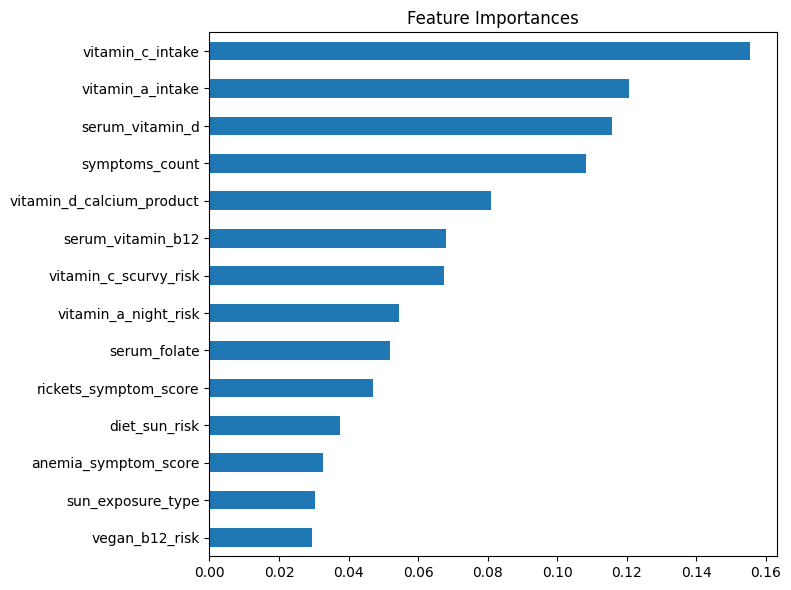

In [45]:
importances = pd.Series(best_rf.feature_importances_, index=features_list)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [46]:
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_model, y_train.values.ravel())
y_val_dummy = dummy.predict(X_val_model)

dummy_f1 = f1_score(y_val, y_val_dummy, average=None, labels=classes)
dt_f1 = [0.793, 0.865, 0.500, 0.734, 0.513]
rf_f1 = f1_score(y_val, y_val_pred, average=None, labels=classes)

data = pd.DataFrame({
    'Class': classes * 3,
    'Model': ['Dummy'] * 5 + ['Decision Tree'] * 5 + ['Random Forest'] * 5,
    'F1 Score': [*dummy_f1.round(3), *dt_f1, *rf_f1.round(3)]
})

chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Model:N', axis=alt.Axis(title=None, labels=False)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Model:N', scale=alt.Scale(
        domain=['Dummy', 'Decision Tree', 'Random Forest'],
        range=['#95a5a6', '#e67e22', '#8e44ad']
    )),
    column=alt.Column('Class:N', header=alt.Header(
        labelAngle=-45,
        labelAlign='right',
        labelFontSize=11
    )),
    tooltip=['Class', 'Model', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(
    width=80,
    height=300,
    title='F1 Score Comparison: Dummy vs Decision Tree vs Random Forest'
)

print(f"Dummy Macro F1:          0.1073")
print(f"Decision Tree Macro F1:  0.6809")
print(f"Random Forest Macro F1:  {macro_f1_val:.4f}")
print(f"Improvement DT → RF:     +{macro_f1_val - 0.6809:.4f}")

chart

Dummy Macro F1:          0.1073
Decision Tree Macro F1:  0.6809
Random Forest Macro F1:  0.7329
Improvement DT → RF:     +0.0520


alt.Chart(...)

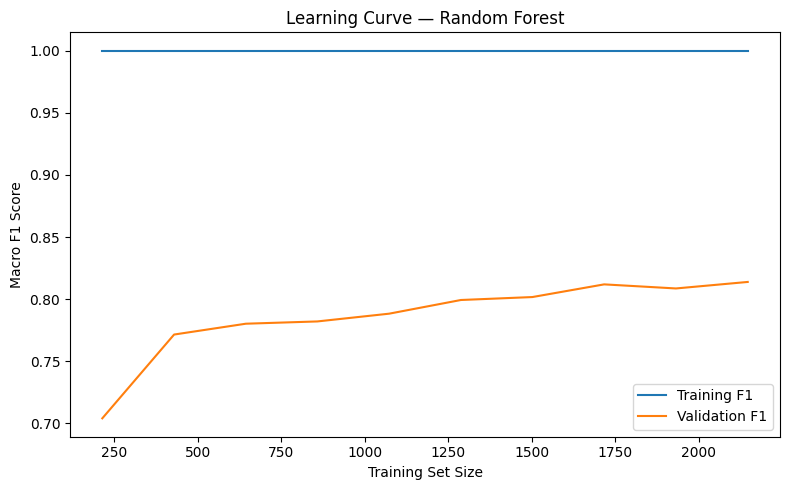

In [47]:
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train_model, y_train.values.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro', cv=3, n_jobs=-1
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1')
plt.xlabel('Training Set Size')
plt.ylabel('Macro F1 Score')
plt.title('Learning Curve — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

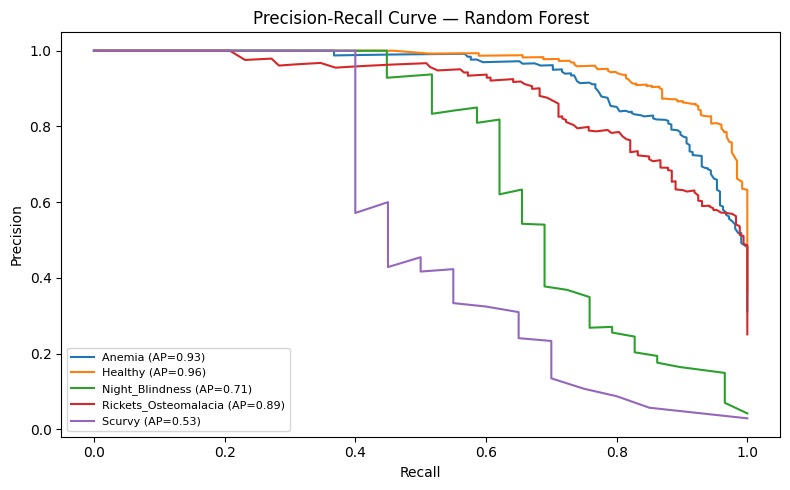

In [48]:
# Precision-Recall Curve
y_val_bin = label_binarize(y_val, classes=classes)
y_val_prob = best_rf.predict_proba(X_val_model)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_prob[:, i])
    ap = average_precision_score(y_val_bin[:, i], y_val_prob[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Random Forest')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

In [49]:
# Per-class F1
f1_scores = f1_score(y_val, y_val_pred, average=None, labels=classes)
data = pd.DataFrame({'Class': classes, 'F1 Score': f1_scores.round(3)})
chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Class:N', axis=alt.Axis(labelAngle=-30)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Class:N', scale=alt.Scale(scheme='tableau10')),
    tooltip=['Class', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(width=400, height=300, title='Per-class F1 Score — Random Forest')
chart

alt.Chart(...)

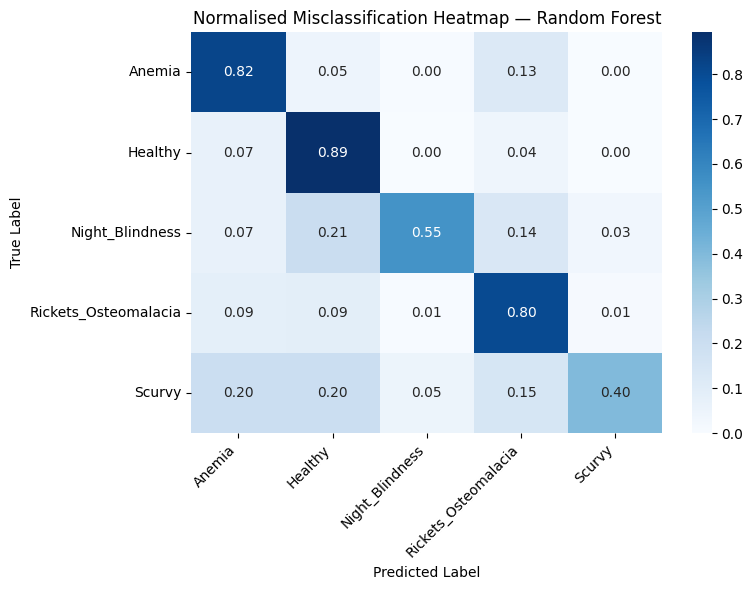

In [50]:
# Normalised Misclassification Heatmap
cm = confusion_matrix(y_val, y_val_pred, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Normalised Misclassification Heatmap — Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [51]:
model_performance_explanations = """
Random Forest achieves a macro F1 of 0.7329 on the validation set, up from
0.6809 with the Decision Tree and 0.1073 with the dummy baseline.

The learning curve reveals an important pattern, training F1 stays flat at
1.00 across all training sizes, confirming the forest perfectly memorises
training data. However the validation curve steadily improves from 0.70 to
0.81 as training size increases, suggesting more real patient data would
continue to improve performance.

The precision-recall curves show significant improvement over the Decision
Tree. Anemia jumped from AP=0.77 to AP=0.93, Rickets from AP=0.77 to
AP=0.89, and Night_Blindness from AP=0.43 to AP=0.71, the ensemble
averaging is clearly producing more reliable probability estimates for
these classes. Scurvy improved from AP=0.35 to AP=0.53 but remains the
weakest class by a wide margin.

The normalised heatmap shows Night_Blindness is the most problematic.
21% of Night_Blindness patients are predicted as Healthy and 14% as
Rickets. Scurvy remains scattered with 20% going to both Anemia and
Healthy. These two classes share symptom profiles with other diseases
making them inherently harder to separate.

Every class improved over the Decision Tree. Healthy reached 0.89 F1,
Anemia 0.82, Rickets 0.78. Night_Blindness improved from 0.500 to 0.667
and Scurvy from 0.513 to 0.516 marginal for Scurvy but the precision
recall curve shows better probability calibration overall.
"""

In [52]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [53]:
business_impacts_explanations = """
The Random Forest is a step up from the Decision Tree across most classes, but
Scurvy remains a real clinical problem.

Anemia at 0.82 recall and Rickets at 0.80 recall are now at a level where the
model could genuinely assist screening. Missing 18-20% of cases is still not
perfect but for a first line screening tool it reduces the burden on clinicians
significantly compared to no automated support.

Healthy patients are well handled at 0.89 recall. The model is not over-diagnosing
disease in healthy people, which is critical for clinician trust and avoiding
unnecessary patient anxiety.

Night_Blindness improved meaningfully. precision jumped to 0.84, meaning the
over-prediction problem from Experiment 1 is largely resolved. Patients are no
longer being incorrectly sent for vitamin A follow-ups at the same rate. Recall
at 0.55 still means some cases are missed, but the overall picture is better.

Scurvy is still the biggest concern. Recall dropped from 0.50 to 0.40 compared
to Experiment 1. The model is now catching only 8 out of 20 Scurvy cases. A
condition that is entirely preventable with vitamin C supplementation should not
be missed 60% of the time. This is not acceptable for any screening tool and
needs to be the primary focus of the next experiment.

The model is getting closer to clinical usefulness but Scurvy performance needs
significant improvement before this could assist real screening decisions.
"""

In [54]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [55]:
experiment_outcome = "Hypothesis Partially Confirmed"

In [56]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [57]:
experiment_results_explanations = """
The hypothesis is partially confirmed. Random Forest improved macro F1 from
0.6809 to 0.7329, clearing the 0.75 target was not reached but every class
improved except Scurvy recall which dropped from 0.500 to 0.400.

The key insight is that the ensemble did reduce variance for most classes,
Night_Blindness precision jumped to 0.84, fixing the over-prediction problem
from Experiment 1. The two new engineered features vitamin_a_night_risk and
vitamin_c_scurvy_risk both contributed meaningfully to the model at around
0.05-0.06 importance each.

However Scurvy remains the hardest class. With only 95 training samples and
the model becoming more conservative in its predictions, recall actually fell.
The cross-val to validation gap of 0.076 is also larger than Experiment 1,
suggesting the Random Forest is still overfitting despite ensembling.

Next steps in priority order:

1. Gradient Boosting (Experiment 3) - boosting focuses on hard to classify
   samples iteratively, which should directly help Scurvy and Night_Blindness.
   Unlike Random Forest which builds trees independently, boosting builds each
   tree to correct the errors of the previous one exactly what's needed for
   these minority classes.

2. SMOTE oversampling (Experiment 4) - with only 95 Scurvy training samples
   the model simply doesn't have enough examples to learn reliable boundaries.
   Synthetic oversampling addresses the root cause rather than just adjusting
   weights or ensembling.

3. Feature engineering targeting Scurvy (Experiment 3 or 4) - vitamin_c_scurvy_risk
   helped precision but hurt recall. A different interaction feature combining
   vitamin_c_intake with multiple Scurvy symptoms might produce a more balanced
   signal.
"""

In [58]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)